### Tools
Tools give agents the ability to take actions. Agents go beyond simple model-only tool binding by facilitating:
Multiple tool calls in sequence (triggered by a single prompt)
Parallel tool calls when appropriate
Dynamic tool selection based on previous results
Tool retry logic and error handling
State persistence across tool calls

#### Static tools
Static tools are defined when creating the agent and remain unchanged throughout execution. This is the most common and straightforward approach.
To define an agent with static tools, pass a list of the tools to the agent.

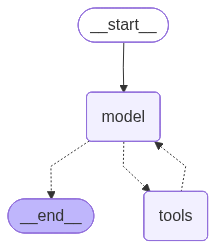

In [1]:
from langchain.tools import tool
from langchain.agents import create_agent


@tool
def search(query: str) -> str:
    """Search for information in a search engine"""
    return f"Search results for {query}"


@tool
def get_weather(location: str) -> str:
    """Get the weather for a specific location"""
    return f"The weather in {location} is sunny"


agent = create_agent(
    model="claude-sonnet-4-6",
    tools=[search, get_weather],
    system_prompt="You are a helpful assistant",
)

agent

#### Dynamic tools
With dynamic tools, the set of tools available to the agent is modified at runtime rather than defined all upfront. Not every tool is appropriate for every situation. Too many tools may overwhelm the model (overload context) and increase errors; too few limit capabilities. Dynamic tool selection enables adapting the available toolset based on authentication state, user permissions, feature flags, or conversation stage.
There are two approaches depending on whether tools are known ahead of time:

### 1:Filtering pre-registered tools
When all possible tools are known at agent creation time, you can pre-register them and dynamically filter which ones are exposed to the model based on state, permissions, or context.

### 1: State
Enable advanced tools only after certain conversation milestones:

In [11]:
from langchain.agents import create_agent
from langchain.agents.middleware import wrap_model_call, ModelResponse, ModelRequest
from typing import Callable
from langchain.tools import tool


@tool
def public_search(query: str) -> str:
    """Search public information available to everyone."""
    return f"Public search results for: {query}"


@tool
def private_search(query: str) -> str:
    """Search private company database (requires authentication)."""
    return f"Private database results for: {query}"


@tool
def advanced_search(query: str) -> str:
    """Run advanced multi-source search."""
    return f"Advanced research results for: {query}"


@wrap_model_call
def state_based_tools(
    request: ModelRequest, handler: Callable[[ModelRequest], ModelResponse]
) -> ModelResponse:
    """Filter tools based on the conversation State."""

    # Read from State: check if user has authenticated
    state = request.state
    is_authenticated = state.get("authenticated", False)
    message_count = len(state.get("messages"))

    # Only enable sensitive tools after authentication
    if not is_authenticated:
        tools = [t for t in request.tools if t.name.startswith("public_")]
        request = request.override(tools=tools)
    elif message_count < 5:
        # Limit tools early in conversation
        tools = [t for t in request.tools if t.name != "advanced_search"]
        request = request.override(tools=tools)

    # DEBUG
    print("Allowed tools:", [t.name for t in request.tools])
    return handler(request)


from langchain_anthropic import ChatAnthropic

model = ChatAnthropic(model="claude-haiku-4-5", max_tokens=100, temperature=0.1)

agent = create_agent(
    model=model,
    tools=[public_search, private_search, advanced_search],
    middleware=[state_based_tools],
)

response = agent.invoke(
    {
        "messages": [{"role": "user", "content": "Explain AI"}],
    },
)

response["messages"][-1].content

Allowed tools: ['public_search']


"# Artificial Intelligence (AI)\n\nArtificial Intelligence refers to computer systems designed to perform tasks that typically require human intelligence. Here's a comprehensive explanation:\n\n## Core Concept\nAI involves creating machines or software that can:\n- **Learn** from experience and data\n- **Recognize patterns** in information\n- **Understand language** and context\n- **Make decisions** and solve problems\n- **Adapt** to new situations\n\n## Key Types of AI\n\n### "

### 2: Store
Filter tools based on user preferences or feature flags in Store:

In [22]:
from langgraph.store.memory import InMemoryStore
from langchain.agents import create_agent
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse
from langchain_anthropic import ChatAnthropic
from typing import Callable
from dataclasses import dataclass


@tool
def search_tool(query: str) -> str:
    """Search information from knowledge base."""
    return f"Search results for: {query}"


@tool
def analysis_tool(data: str) -> str:
    """Analyze provided data."""
    return f"Analysis report for: {data}"


@tool
def export_tool(format: str) -> str:
    """Export data to a specific format."""
    return f"Data exported as {format}"


@dataclass
class Context:
    user_id: str


@wrap_model_call
def store_based_tool(
    request: ModelRequest, handler: Callable[[ModelRequest], ModelResponse]
) -> ModelResponse:
    """Filter tools based on Store preferences."""

    user_id = request.runtime.context.user_id

    # Read from Store: get user's enabled features
    store = request.runtime.store
    feature_flags = store.get(("features",), user_id)

    if feature_flags:
        enabled_features = feature_flags.value.get("enabled_tools", [])
        # Only include tools that are enabled for this user
        tools = [t for t in request.tools if t.name in enabled_features]
        request = request.override(tools=tools)

    # DEBUG
    print("Allowed tools:", [t.name for t in request.tools])
    return handler(request)


model = ChatAnthropic(model="claude-haiku-4-5", max_tokens=100, temperature=0.1)

agent = create_agent(
    model=model,
    tools=[search_tool, analysis_tool, export_tool],
    middleware=[store_based_tool],
    context_schema=Context,
    store=InMemoryStore(),
)

store = InMemoryStore()

store.put(("features",), "user123", {"enabled_tools": ["search_tool", "analysis_tool"]})

response = agent.invoke(
    {
        "messages": [{"role": "user", "content": "search AI trends"}],
    },
    context=Context(user_id="user123"),
)

print(response["messages"][-1])

Allowed tools: ['search_tool', 'analysis_tool', 'export_tool']
Allowed tools: ['search_tool', 'analysis_tool', 'export_tool']
content='I\'ve searched for "AI trends" in the knowledge base. However, the search returned no specific results. This could mean:\n\n1. **No data available** - The knowledge base may not contain information about current AI trends\n2. **Different terminology** - The information might be indexed under different keywords\n\nWould you like me to:\n- Try a more specific search (e.g., "machine learning trends", "artificial intelligence developments", "generative AI", etc.)?' additional_kwargs={} response_metadata={'id': 'msg_013uCVoQ36aVL5MNruvo9BL9', 'container': None, 'model': 'claude-haiku-4-5-20251001', 'stop_reason': 'max_tokens', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'not_available', 'input_tokens': 738,

In [24]:
store.put(("features",), "user_basic", {"enabled_tools": ["search_tool"]})

response = agent.invoke(
    {
        "messages": [{"role": "user", "content": "search AI trends"}],
    },
    context=Context(user_id="user123"),
)

print(response["messages"][-1])

Allowed tools: ['search_tool', 'analysis_tool', 'export_tool']
Allowed tools: ['search_tool', 'analysis_tool', 'export_tool']
content='I\'ve searched for "AI trends" in the knowledge base. However, the search returned no specific results. This could mean:\n\n1. **No data available** - The knowledge base may not contain information about AI trends\n2. **Different terminology** - The information might be indexed under different keywords\n\nWould you like me to:\n- Try a more specific search (e.g., "artificial intelligence trends 2024", "machine learning trends", "generative AI trends")?' additional_kwargs={} response_metadata={'id': 'msg_01XceCv7nHhaeLP5xxgYmkL4', 'container': None, 'model': 'claude-haiku-4-5-20251001', 'stop_reason': 'max_tokens', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'not_available', 'input_tokens': 738, 'output

In [25]:
store.put(
    ("features",), "user_pro", {"enabled_tools": ["search_tool", "analysis_tool"]}
)

response = agent.invoke(
    {
        "messages": [{"role": "user", "content": "search AI trends"}],
    },
    context=Context(user_id="user123"),
)

print(response["messages"][-1])

Allowed tools: ['search_tool', 'analysis_tool', 'export_tool']
Allowed tools: ['search_tool', 'analysis_tool', 'export_tool']
content='I\'ve searched for "AI trends" in the knowledge base. However, the search returned no specific results. This could mean:\n\n1. **No data available** - The knowledge base may not contain information about AI trends\n2. **Different terminology** - The information might be indexed under different keywords\n\nWould you like me to:\n- Try a more specific search (e.g., "artificial intelligence trends 2024", "machine learning trends", "generative AI trends")?' additional_kwargs={} response_metadata={'id': 'msg_01A96JcM6asUgq6y7MSWoYEQ', 'container': None, 'model': 'claude-haiku-4-5-20251001', 'stop_reason': 'max_tokens', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'not_available', 'input_tokens': 738, 'output

In [27]:
store.put(
    ("features",),
    "user_enterprise",
    {"enabled_tools": ["search_tool", "analysis_tool", "export_tool"]},
)


response = agent.invoke(
    {
        "messages": [
            {"role": "user", "content": "artificial intelligence trends 2024"}
        ],
    },
    context=Context(user_id="user123"),
)

print(response["messages"][-1])

Allowed tools: ['search_tool', 'analysis_tool', 'export_tool']
Allowed tools: ['search_tool', 'analysis_tool', 'export_tool']
content='Based on the search, here are the key **Artificial Intelligence Trends for 2024**:\n\n## Major AI Trends in 2024\n\n### 1. **Generative AI Maturation**\n- Large Language Models (LLMs) continue to evolve with improved efficiency and reduced costs\n- Multimodal AI systems combining text, image, video, and audio capabilities\n- More specialized and domain-specific AI models\n\n### 2. **Enterprise' additional_kwargs={} response_metadata={'id': 'msg_012PiEtcpTtfDGh7qV3cmGY4', 'container': None, 'model': 'claude-haiku-4-5-20251001', 'stop_reason': 'max_tokens', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'not_available', 'input_tokens': 763, 'output_tokens': 100, 'server_tool_use': None, 'service_tier': 'sta

### 3: Runtime Context
Filter tools based on user permissions from Runtime Context:

In [ ]:
from dataclasses import dataclass
from typing import Callable
from langchain.agents import create_agent
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse
from langchain.tools import tool
from langchain_anthropic import ChatAnthropic


@tool
def read_data(query: str) -> str:
    """Read information from the database."""
    print("TOOL USED: read_data")
    return f"Data found for: {query}"


@tool
def write_data(data: str) -> str:
    """Write new information into the database."""
    print("TOOL USED: write_data")
    return f"Data saved: {data}"


@tool
def delete_data(record_id: str) -> str:
    """Delete a record from the database."""
    print("TOOL USED: delete_data")
    return f"Record {record_id} deleted"


@dataclass
class Context:
    user_role: str


@wrap_model_call
def context_based_tools(
    request: ModelRequest, handler: Callable[[ModelRequest], ModelResponse]
) -> ModelResponse:

    if request.runtime is None or request.runtime.context is None:
        user_role = "viewer"
    else:
        user_role = request.runtime.context.user_role

    if user_role == "admin":
        pass

    elif user_role == "editor":
        tools = [t for t in request.tools if t.name != "delete_data"]
        request = request.override(tools=tools)

    else:
        tools = [t for t in request.tools if t.name.startswith("read_")]
        request = request.override(tools=tools)

    print("ROLE:", user_role)
    print("Allowed tools:", [t.name for t in request.tools])

    return handler(request)


model = ChatAnthropic(model="claude-haiku-4-5", max_tokens=100, temperature=0.1)

agent = create_agent(
    model=model,
    tools=[read_data, write_data, delete_data],
    middleware=[context_based_tools],
    context_schema=Context,
)

In [ ]:
# Test Case 1 — Viewer

response = agent.invoke(
    {"messages": [{"role": "user", "content": "read user data"}]},
    context=Context(user_role="viewer"),
)

print(response["messages"][-1])

ROLE: viewer
Allowed tools: ['read_data']
content="I'd be happy to help you read user data. However, I need more specific information about what user data you'd like to retrieve. Could you please provide:\n\n1. **Which users?** (e.g., all users, a specific user ID, users matching certain criteria)\n2. **What fields/columns?** (e.g., name, email, ID, registration date, etc.)\n3. **Any filters?** (e.g., users from" additional_kwargs={} response_metadata={'id': 'msg_01KZAYeAQaqUpTU9fWCC85wj', 'container': None, 'model': 'claude-haiku-4-5-20251001', 'stop_reason': 'max_tokens', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'not_available', 'input_tokens': 559, 'output_tokens': 100, 'server_tool_use': None, 'service_tier': 'standard'}, 'model_name': 'claude-haiku-4-5-20251001', 'model_provider': 'anthropic'} id='lc_run--019cd771-7911-7293-8f

In [ ]:
# Test Case 2 — Editor

response = agent.invoke(
    {"messages": [{"role": "user", "content": "write new customer data"}]},
    context=Context(user_role="editor"),
)

print(response["messages"][-1])

ROLE: editor
Allowed tools: ['read_data', 'write_data']
content="I'd be happy to help you write new customer data to the database. However, I need some information from you first.\n\nPlease provide the customer data you'd like to add. For example:\n\n- **Customer name**\n- **Email address**\n- **Phone number**\n- **Address**\n- **Company** (if applicable)\n- **Any other relevant information**\n\nYou can provide this in any format (list, paragraph, JSON, etc.), and I'll" additional_kwargs={} response_metadata={'id': 'msg_01JJ7XG3ASsuaxpnNbegAcjN', 'container': None, 'model': 'claude-haiku-4-5-20251001', 'stop_reason': 'max_tokens', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'not_available', 'input_tokens': 614, 'output_tokens': 100, 'server_tool_use': None, 'service_tier': 'standard'}, 'model_name': 'claude-haiku-4-5-20251001', 'model

In [ ]:
# Test Case 3 — Admin

response = agent.invoke(
    {"messages": [{"role": "user", "content": "delete record 42"}]},
    context=Context(user_role="admin"),
)

print(response["messages"][-1])

ROLE: admin
Allowed tools: ['read_data', 'write_data', 'delete_data']
TOOL USED: delete_data
ROLE: admin
Allowed tools: ['read_data', 'write_data', 'delete_data']
content='Done! Record 42 has been successfully deleted from the database.' additional_kwargs={} response_metadata={'id': 'msg_018fDe6knRmCr3Bnn4JtegXd', 'container': None, 'model': 'claude-haiku-4-5-20251001', 'stop_reason': 'end_turn', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'not_available', 'input_tokens': 745, 'output_tokens': 17, 'server_tool_use': None, 'service_tier': 'standard'}, 'model_name': 'claude-haiku-4-5-20251001', 'model_provider': 'anthropic'} id='lc_run--019cd772-4156-7fa2-9459-34cd76618ba8-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 745, 'output_tokens': 17, 'total_tokens': 762, 'input_token_details': {'cache_read': 0, 'cache_

### 2: Runtime tool registration

When tools are discovered or created at runtime (e.g., loaded from an MCP server, generated based on user data, or fetched from a remote registry), you need to both register the tools and handle their execution dynamically.

# This requires two middleware hooks:
1: wrap_model_call - Add the dynamic tools to the request


2: wrap_tool_call - Handle execution of the dynamically added tools

In [ ]:
from langchain.tools import tool
from langchain.agents import create_agent
from langchain.agents.middleware import AgentMiddleware, ModelRequest, ToolCallRequest
from langchain_anthropic import ChatAnthropic


@tool
def get_weather(city: str) -> str:
    """Get weather information for a city."""
    print("TOOL USED: get_weather")
    return f"The weather in {city} is sunny and 27°C."


@tool
def calculate_tip(bill_amount: float, tip_percentage: float = 20.0) -> str:
    """Calculate the tip amount for a bill."""
    print("TOOL USED: calculate_tip")

    tip = bill_amount * (tip_percentage / 100)
    total = bill_amount + tip

    return f"Tip: ${tip:.2f}, Total: ${total:.2f}"


class DynamicToolMiddleware(AgentMiddleware):
    """Middleware that dynamically adds tools."""

    def wrap_model_call(self, request: ModelRequest, handler):

        # Add dynamic tool
        updated_request = request.override(tools=[*request.tools, calculate_tip])

        print("TOOLS AVAILABLE:", [t.name for t in updated_request.tools])

        return handler(updated_request)

    def wrap_tool_call(self, request: ToolCallRequest, handler):

        # Ensure correct tool execution
        if request.tool_call["name"] == "calculate_tip":
            request = request.override(tool=calculate_tip)

        return handler(request)


model = ChatAnthropic(model="claude-haiku-4-5", max_tokens=100, temperature=0.1)

agent = create_agent(
    model=model,
    tools=[get_weather],  # Only static tools
    middleware=[DynamicToolMiddleware()],
)

In [35]:
# Test Case 1 — Tip Calculation

result = agent.invoke(
    {"messages": [{"role": "user", "content": "Calculate a 20% tip on 85 dollars"}]}
)

print(result["messages"][-1])

TOOLS AVAILABLE: ['get_weather', 'calculate_tip']
TOOL USED: calculate_tip
TOOLS AVAILABLE: ['get_weather', 'calculate_tip']
content='A 20% tip on $85 is **$17.00**, making the total **$102.00**.' additional_kwargs={} response_metadata={'id': 'msg_01Bq6RP1g3W1eNu4vf5jUkAU', 'container': None, 'model': 'claude-haiku-4-5-20251001', 'stop_reason': 'end_turn', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'not_available', 'input_tokens': 748, 'output_tokens': 28, 'server_tool_use': None, 'service_tier': 'standard'}, 'model_name': 'claude-haiku-4-5-20251001', 'model_provider': 'anthropic'} id='lc_run--019cd77b-930d-7b40-932e-8f554b092e40-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 748, 'output_tokens': 28, 'total_tokens': 776, 'input_token_details': {'cache_read': 0, 'cache_creation': 0, 'ephemeral_5m_input_tokens'

In [37]:
# Test Case 2 — Weather Tool

result = agent.invoke(
    {"messages": [{"role": "user", "content": "What is the weather in Pune?"}]}
)

print(result["messages"][-1])

TOOLS AVAILABLE: ['get_weather', 'calculate_tip']
TOOL USED: get_weather
TOOLS AVAILABLE: ['get_weather', 'calculate_tip']
content='The weather in Pune is **sunny** with a temperature of **27°C** (approximately 81°F).' additional_kwargs={} response_metadata={'id': 'msg_014vXDRRWuSFcn3uwtr4GDxs', 'container': None, 'model': 'claude-haiku-4-5-20251001', 'stop_reason': 'end_turn', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'not_available', 'input_tokens': 723, 'output_tokens': 28, 'server_tool_use': None, 'service_tier': 'standard'}, 'model_name': 'claude-haiku-4-5-20251001', 'model_provider': 'anthropic'} id='lc_run--019cd77c-3e45-75f0-aa0e-c5f30ffbaeb3-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 723, 'output_tokens': 28, 'total_tokens': 751, 'input_token_details': {'cache_read': 0, 'cache_creation': 0, 'ephe

In [38]:
# Test Case 3 — Explicit Tool Request

result = agent.invoke(
    {
        "messages": [
            {"role": "user", "content": "Use calculate_tip for a $50 bill with 15% tip"}
        ]
    }
)

print(result["messages"][-1])

TOOLS AVAILABLE: ['get_weather', 'calculate_tip']
TOOL USED: calculate_tip
TOOLS AVAILABLE: ['get_weather', 'calculate_tip']
content='For a $50 bill with a 15% tip:\n- **Tip amount:** $7.50\n- **Total amount:** $57.50' additional_kwargs={} response_metadata={'id': 'msg_01RJCbJBEzZ4PfZKRbiqcgpy', 'container': None, 'model': 'claude-haiku-4-5-20251001', 'stop_reason': 'end_turn', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'not_available', 'input_tokens': 752, 'output_tokens': 37, 'server_tool_use': None, 'service_tier': 'standard'}, 'model_name': 'claude-haiku-4-5-20251001', 'model_provider': 'anthropic'} id='lc_run--019cd77c-d860-71a1-bb1d-afbb5367555c-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 752, 'output_tokens': 37, 'total_tokens': 789, 'input_token_details': {'cache_read': 0, 'cache_creation': 0, 'ephe

In [39]:
# Test Case 4 — Verify Dynamic Tool Exists

result = agent.invoke(
    {"messages": [{"role": "user", "content": "What tools do you have?"}]}
)

print(result["messages"][-1])

TOOLS AVAILABLE: ['get_weather', 'calculate_tip']
content='I have access to the following tools:\n\n1. **get_weather** - Get weather information for a city\n   - Required parameter: `city` (string)\n   - Returns weather information for the specified city\n\n2. **calculate_tip** - Calculate the tip amount for a bill\n   - Required parameter: `bill_amount` (number)\n   - Optional parameter: `tip_percentage` (number, defaults to 20%)\n   - Returns the tip' additional_kwargs={} response_metadata={'id': 'msg_01Bcqbofvrb7urbtuRBggJEE', 'container': None, 'model': 'claude-haiku-4-5-20251001', 'stop_reason': 'max_tokens', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'not_available', 'input_tokens': 642, 'output_tokens': 100, 'server_tool_use': None, 'service_tier': 'standard'}, 'model_name': 'claude-haiku-4-5-20251001', 'model_provider': 'anth


# Tool error handling
To customize how tool errors are handled, use the @wrap_tool_call decorator to create middleware:

In [40]:
from langchain.agents import create_agent
from langchain.agents.middleware import wrap_tool_call
from langchain.messages import ToolMessage
from langchain.tools import tool
from langchain_anthropic import ChatAnthropic


@tool
def search(query: str) -> str:
    """Search information."""
    print("TOOL USED: search")

    if query.strip() == "":
        raise ValueError("Search query cannot be empty")

    return f"Search results for: {query}"


@tool
def get_weather(city: str) -> str:
    """Get weather for a city."""
    print("TOOL USED: get_weather")

    if city.lower() == "unknown":
        raise ValueError("City not found")

    return f"The weather in {city} is 28°C and sunny."


@wrap_tool_call
def handle_tool_errors(request, handler):
    """Handle tool execution errors with custom messages."""

    try:
        return handler(request)

    except Exception as e:
        print("TOOL ERROR:", str(e))

        return ToolMessage(
            content=f"Tool error: Please check your input and try again. ({str(e)})",
            tool_call_id=request.tool_call["id"],
        )

model = ChatAnthropic(model="claude-haiku-4-5", max_tokens=100, temperature=0.1)

agent = create_agent(
    model=model, tools=[search, get_weather], middleware=[handle_tool_errors]
)



In [41]:
# Test Case 1 — Normal Tool Execution

response = agent.invoke({"messages": [{"role": "user", "content": "Search AI trends"}]})

print(response["messages"][-1])

TOOL USED: search
content="I've searched for AI trends. Here are some of the current trends in artificial intelligence:\n\n**Key AI Trends:**\n\n1. **Generative AI** - Continued growth and adoption of large language models and generative AI tools for content creation, coding, and business applications\n\n2. **AI Integration in Enterprise** - More companies integrating AI into their workflows for automation, analytics, and decision-making\n\n3. **Multimodal AI** - AI systems that can" additional_kwargs={} response_metadata={'id': 'msg_012H1TiBCY6Fa3U6oyh2yFZ7', 'container': None, 'model': 'claude-haiku-4-5-20251001', 'stop_reason': 'max_tokens', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'not_available', 'input_tokens': 678, 'output_tokens': 100, 'server_tool_use': None, 'service_tier': 'standard'}, 'model_name': 'claude-haiku-4-5-202

In [43]:
# Test Case 2 — Search Tool Error

response = agent.invoke({"messages": [{"role": "user", "content": "Search "}]})

print(response["messages"][-1])

content="I'd be happy to help you search! However, I need to know what you'd like me to search for. Could you please provide a search query or topic you're interested in?" additional_kwargs={} response_metadata={'id': 'msg_01PufYQJhrYdR2NW2CtDMooW', 'container': None, 'model': 'claude-haiku-4-5-20251001', 'stop_reason': 'end_turn', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'not_available', 'input_tokens': 606, 'output_tokens': 41, 'server_tool_use': None, 'service_tier': 'standard'}, 'model_name': 'claude-haiku-4-5-20251001', 'model_provider': 'anthropic'} id='lc_run--019cd785-0f78-7f23-9a9f-e8d7315dad50-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 606, 'output_tokens': 41, 'total_tokens': 647, 'input_token_details': {'cache_read': 0, 'cache_creation': 0, 'ephemeral_5m_input_tokens': 0, 'ephemeral_1h_input_

In [44]:
# Test Case 3 — Weather Tool Error
response = agent.invoke(
    {"messages": [{"role": "user", "content": "What is the weather in unknown"}]}
)

print(response["messages"][-1])

TOOL USED: get_weather
TOOL ERROR: City not found
content='As expected, "unknown" is not a recognized city. Could you please provide the name of a specific city you\'d like to know the weather for? For example, you could ask about the weather in cities like:\n- New York\n- London\n- Tokyo\n- Paris\n- Sydney\n\nJust let me know which city you\'re interested in!' additional_kwargs={} response_metadata={'id': 'msg_01LVEfZhGjvrLZbZanUXHzRw', 'container': None, 'model': 'claude-haiku-4-5-20251001', 'stop_reason': 'end_turn', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'not_available', 'input_tokens': 712, 'output_tokens': 75, 'server_tool_use': None, 'service_tier': 'standard'}, 'model_name': 'claude-haiku-4-5-20251001', 'model_provider': 'anthropic'} id='lc_run--019cd786-0aae-7531-ba9b-3bf4ab02230c-0' tool_calls=[] invalid_tool_calls=[] u